# Uncertainty quantification on ensemble of models

This notebook is an overly simplified illustration of what is availavle on [https://github.com/Loop3D/loopUI](https://github.com/Loop3D/loopUI). 
It illustrates a few pre-computed uncertainty indicators for a synthetic case study based on a comparison of three sampling scenarios. Each scenario consists of 10 stochastic geological models generated with [LoopStructural](https://github.com/Loop3D/LoopStructural).

<img src="img/synthetic_case_3_scenarios.png" alt="A synthetic case, inspired by a Hamersley dataset" style="width: 600px;"/>

*Figure1: illustration of the synbthetic case, inspired by a Hamersley dataset* [*(Pirot et al., 2022)*](https://doi.org/10.5194/gmd-15-4689-2022)

The three following indicators are illustrated:
1. Entropy (local indicator)
2. Histogram-based dissimilarity (global indicator)
3. Wavelet-based dissimilarity (global indicator)

Required $Python$ libraries to run this notebook:
 - `pickle`
 - `matplotlib`
 - `sklearn`

In [1]:
if 'google.colab' in str(get_ipython()):
    print('Running on CoLab')
    # FOLDERNAME PATH ON GOOGLE DRIVE CONTAINING CODE AND DATA
    fdname = "/content/drive/MyDrive/UncertaintyAnalysis/"
    from google.colab import drive
    drive.mount('/content/drive')
    import sys
    sys.path.insert(0,fdname)
else:
    print('Not running on CoLab')
    fdname = "./"

Not running on CoLab


In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors as mcolors
from sklearn import manifold

In [3]:
# FILE NAMES OF PRECOMPUTED DATA
entropy_fn = fdname+"ui_data/synthetic-case-entropy.pickle"
hist_dist_fn = fdname+"ui_data/synthetic-case-histogram.pickle"
wvt_dist_fn = fdname+"ui_data/synthetic-case-wavelet.pickle"

In [4]:
# IMPORT DATA
with open(entropy_fn, 'rb') as f:
    [ent_lc_100,ent_lc_50A,ent_lc_50B,_,_,_] = pickle.load(f)

with open(hist_dist_fn, 'rb') as f:
    [dist_hist_lc,_] = pickle.load(f)

with open(wvt_dist_fn, 'rb') as f:
    [dist_wvt_lc,_] = pickle.load(f)

now we can check the shape of the loaded data arrays

In [5]:
print('**************************************')
print('Entropy cube dimensions for scenario 1 (nz,ny,nx): '+str(ent_lc_100.shape))
print('Entropy cube dimensions for scenario 2 (nz,ny,nx): '+str(ent_lc_50A.shape))
print('Entropy cube dimensions for scenario 3 (nz,ny,nx): '+str(ent_lc_50B.shape))
print('**************************************')
print('Histogram-based dissimiarity matrix dimensions (nsamples,nsamples): '+str(dist_hist_lc.shape))
print('**************************************')
print('Wavelet-based dissimiarity matrix dimensions (nsamples,nsamples): '+str(dist_wvt_lc.shape))
print('**************************************')

**************************************
Entropy cube dimensions for scenario 1 (nz,ny,nx): (33, 113, 103)
Entropy cube dimensions for scenario 2 (nz,ny,nx): (33, 113, 103)
Entropy cube dimensions for scenario 3 (nz,ny,nx): (33, 113, 103)
**************************************
Histogram-based dissimiarity matrix dimensions (nsamples,nsamples): (30, 30)
**************************************
Wavelet-based dissimiarity matrix dimensions (nsamples,nsamples): (30, 30)
**************************************


### Entropy maps or voxets as a local measure of uncertainty
Here we use Shanon's entropy (See e.g. https://en.wikipedia.org/wiki/Entropy_(information_theory)).

Let us consider the variable $X$ that represent a voxel property and assume that it can take $n$ distinct values among an ensemble of voxets. By denoting the probability of observing the $i^{th}$ possible value as $p_i$, the entropy $H$ of $X$ is computed as follows:

$$
H(X)=-\sum \limits _{i=1} ^{n} p_i \ln p_i
$$

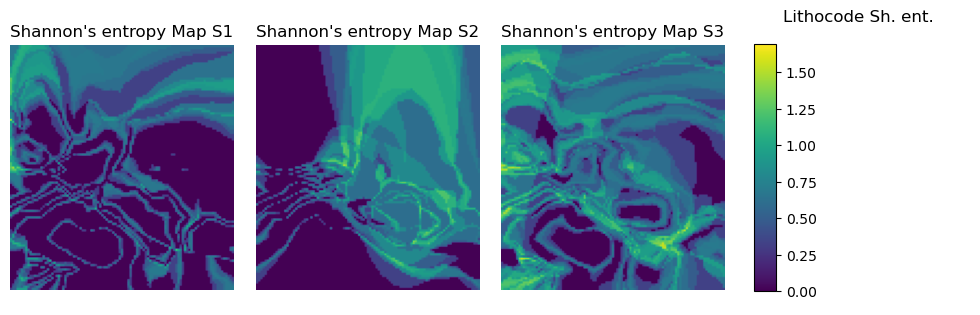

In [6]:
# plotting parameters
slice_iz=7

# figure
fig, ax = plt.subplots(1,4,figsize=(6,2.2))
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[3].axis('off')
axins03 = inset_axes(ax[3],
                   width="10%",  # width = 5% of parent_bbox width
                   height="90%",  # height : 50%
                   loc='center left'
                   )
ax[0].set_title('Shannon\'s entropy Map S1')
ax[1].set_title('Shannon\'s entropy Map S2') # 'entropy W (N) E'
ax[2].set_title('Shannon\'s entropy Map S3') # 'entropy N (W) S'
ax[3].set_title('Lithocode Sh. ent.')
vmin = np.min([np.min(ent_lc_100),np.min(ent_lc_50A),np.min(ent_lc_50B)])
vmax = np.max([np.max(ent_lc_100),np.max(ent_lc_50A),np.max(ent_lc_50B)])
pos00 = ax[0].imshow(ent_lc_100[slice_iz,:,:],origin='lower',cmap='viridis',vmin=vmin,vmax=vmax)
ax[1].imshow(ent_lc_50A[slice_iz,:,:],origin='lower',cmap='viridis',vmin=vmin,vmax=vmax) # .imshow(ent[:,0,:],cmap='viridis',vmin=vmin,vmax=vmax)
ax[2].imshow(ent_lc_50B[slice_iz,:,:],origin='lower',cmap='viridis',vmin=vmin,vmax=vmax) # .imshow(ent[:,:,0],cmap='viridis',vmin=vmin,vmax=vmax)
fig.colorbar(pos00,cax=axins03)  #,label=clblab
fig.subplots_adjust(left=0.0, bottom=0.0, right=1.6, top=1.25, wspace=0.1, hspace=0.2)
plt.show()

### Dissimilarity based on histogram analysis
Each voxet (geological model) produces an histogram of values. The distance between two histograms is computed as the [Jensen-Shanon divergence](https://en.wikipedia.org/wiki/Jensen%E2%80%93Shannon_divergence), a symmetrized and smooth version of the [Kullback-Leibler divergence](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence).

Given two random variables $P$ and $Q$, the Jensen-Shannon divergence is computed as:  
$$
\text{JSD}(P||Q) = \frac{1}{2} \text{KLD}(P||M) + \frac{1}{2} \text{KLD}(Q||M),
$$
where $M = \frac{P + Q}{2}$ and KLD is the Kullback-Leibler divergence.

It requires $P$ and $Q$ to share the same support $\mathcal{X}$ and can be computed for continuous or discrete variables. Here, we assume that the support of our random variables is discrete and of size $n$ (possibly $n$ bins for discretized continuous variables).

Denoting the support of $P$ and $Q$ by $(x_i)_{i=1 \dots n}$, $p_i = \text{Prob}(P = x_i)$, $q_i = \text{Prob}(Q = x_i)$, and $m_i = \frac{p_i + q_i}{2}$, the Jensen-Shannon divergence is computed as:
$$
\text{JSD}(P||Q) = \frac{1}{2} \sum_{i=1}^{n} p_i \ln \left( \frac{p_i}{m_i} \right) + \frac{1}{2} \sum_{i=1}^{n} q_i \ln \left( \frac{q_i}{m_i} \right).
$$

The histogram-based dissimilarity matrix is 30 by 30, as there are 10 models for each of the 3 scenarios (30 realizations in total).  
Let's have a look at it in two different ways!


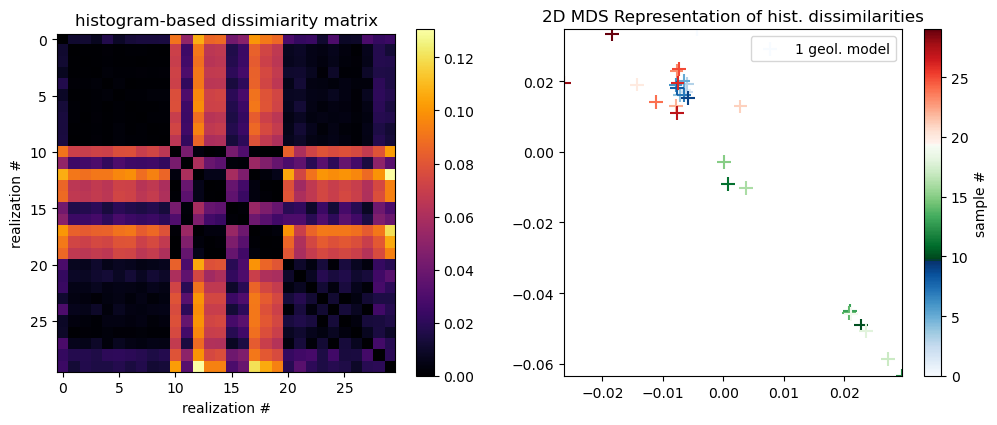

In [7]:
nbsamples = 10

mds = manifold.MDS(n_components=2, max_iter=3000, eps=1e-9, random_state=1234,
                   dissimilarity="precomputed", n_jobs=1)

mdspos_lc = mds.fit(dist_hist_lc).embedding_

s_id = np.arange(nbsamples*3)
# Plot concentric circle dataset
colors1 = plt.cm.Blues(np.linspace(0., 1, 512))
colors2 = np.flipud(plt.cm.Greens(np.linspace(0, 1, 512)))
colors3 = plt.cm.Reds(np.linspace(0, 1, 512))
colors = np.vstack((colors1, colors2, colors3))
mycmap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

ix=np.tril_indices(nbsamples*3,k=-1)

lcmin = np.amin(dist_hist_lc[ix]) 
lcmax = np.amax(dist_hist_lc[ix])

lcMDSxmin = np.min(mdspos_lc[:,0])
lcMDSxmax = np.max(mdspos_lc[:,0])
lcMDSymin = np.min(mdspos_lc[:,1])
lcMDSymax = np.max(mdspos_lc[:,1])

s = 100

plt.subplots(1,2,figsize=(12,4.5))
plt.subplot(121)
plt.imshow(dist_hist_lc,cmap='inferno'),plt.colorbar()
plt.xlabel('realization #')
plt.ylabel('realization #')
plt.title('histogram-based dissimiarity matrix')
plt.subplot(122)
plt.title('2D MDS Representation of hist. dissimilarities')
plt.scatter(mdspos_lc[:, 0], mdspos_lc[:, 1], c=s_id,cmap=mycmap, s=s, label='1 geol. model', marker='+')
plt.xlim(lcMDSxmin,lcMDSxmax)
plt.ylim(lcMDSymin,lcMDSymax)
plt.legend(scatterpoints=1, loc='best', shadow=False)
cbar = plt.colorbar()
cbar.set_label('sample #')
plt.show()

### Dissimilarity based on wavelet decomposition
Wavelet decomposition is way to compress images. Each level of decomposition produces a series of coefficients. If computed for images to be compared, the dissimilarity of histogram of coefficients can be computed with the Jenson-Shannon divergence.

Wavelet decomposition is performed with the *PyWavelets* Python package [Lee et al., 2019]. Detailed documentation is avilable at: https://pywavelets.readthedocs.io/en/latest/ .

##### References
Gregory R. Lee, Ralf Gommers, Filip Wasilewski, Kai Wohlfahrt, Aaron O’Leary (2019). PyWavelets: A Python package for wavelet analysis. Journal of Open Source Software, 4(36), 1237, https://doi.org/10.21105/joss.01237.

The wavelet-based dissimiarity matrix is 30 by 30, as there are 10 models for each of the 3 scenario (30 realizations in total).<br>
Let's have a look at it in two different ways!

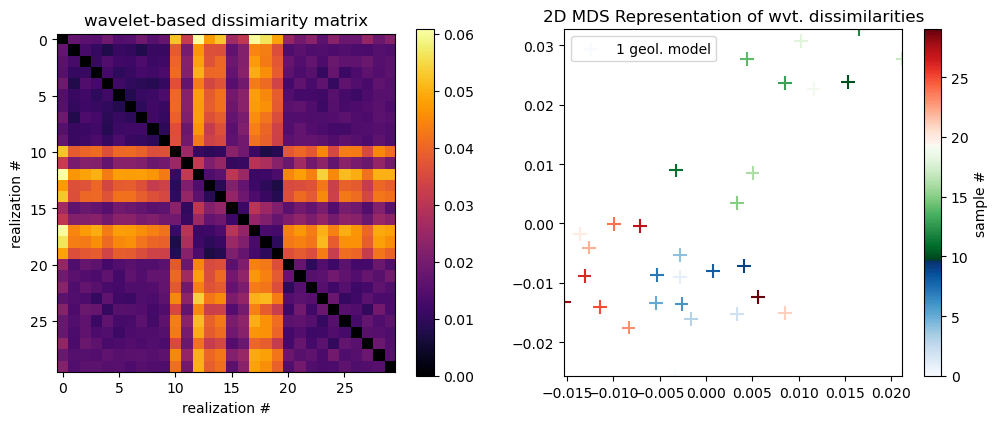

In [8]:
nbsamples = 10

mds = manifold.MDS(n_components=2, max_iter=3000, eps=1e-9, random_state=1234,
                   dissimilarity="precomputed", n_jobs=1)

mdspos_lc = mds.fit(dist_wvt_lc).embedding_

s_id = np.arange(nbsamples*3)
# Plot concentric circle dataset
colors1 = plt.cm.Blues(np.linspace(0., 1, 512))
colors2 = np.flipud(plt.cm.Greens(np.linspace(0, 1, 512)))
colors3 = plt.cm.Reds(np.linspace(0, 1, 512))
colors = np.vstack((colors1, colors2, colors3))
mycmap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

ix=np.tril_indices(nbsamples*3,k=-1)

lcmin = np.amin(dist_wvt_lc[ix]) 
lcmax = np.amax(dist_wvt_lc[ix])

lcMDSxmin = np.min(mdspos_lc[:,0])
lcMDSxmax = np.max(mdspos_lc[:,0])
lcMDSymin = np.min(mdspos_lc[:,1])
lcMDSymax = np.max(mdspos_lc[:,1])

s = 100

plt.subplots(1,2,figsize=(12,4.5))
plt.subplot(121)
plt.imshow(dist_wvt_lc,cmap='inferno'),plt.colorbar()
plt.xlabel('realization #')
plt.ylabel('realization #')
plt.title('wavelet-based dissimiarity matrix')
plt.subplot(122)
plt.title('2D MDS Representation of wvt. dissimilarities')
plt.scatter(mdspos_lc[:, 0], mdspos_lc[:, 1], c=s_id,cmap=mycmap, s=s, label='1 geol. model', marker='+')
plt.xlim(lcMDSxmin,lcMDSxmax)
plt.ylim(lcMDSymin,lcMDSymax)
plt.legend(scatterpoints=1, loc='best', shadow=False)
cbar = plt.colorbar()
cbar.set_label('sample #')
plt.show()